In [1]:
import pandas as pd

data = {
    "Category": [
        "Electronics","Accessories","Clothing","Electronics","Accessories",
        "Clothing","Electronics","Accessories","Clothing","Electronics",
        "Accessories","Clothing","Electronics","Accessories","Clothing",
        "Electronics","Accessories","Clothing","Electronics","Accessories"
    ],

    "Price": [
        500,50,700,30,60,650,40,55,720,35,
        65,680,45,70,750,50,80,800,60,90
    ],

    "UnitsSold": [
        40,120,35,200,110,45,180,130,38,210,
        115,50,170,125,42,190,140,36,175,135
    ],

    "AdSpend": [
        2000,800,2500,600,900,2400,600,850,2600,650,
        950,2300,650,1000,2700,700,1100,2800,750,1200
    ],

    "ProductID": [
        2,4,3,6,4,3,5,4,3,5,
        4,3,5,4,3,5,4,3,5,4
    ]
}

df = pd.DataFrame(data)
print(df)
df.groupby(df["Category"]).describe()

       Category  Price  UnitsSold  AdSpend  ProductID
0   Electronics    500         40     2000          2
1   Accessories     50        120      800          4
2      Clothing    700         35     2500          3
3   Electronics     30        200      600          6
4   Accessories     60        110      900          4
5      Clothing    650         45     2400          3
6   Electronics     40        180      600          5
7   Accessories     55        130      850          4
8      Clothing    720         38     2600          3
9   Electronics     35        210      650          5
10  Accessories     65        115      950          4
11     Clothing    680         50     2300          3
12  Electronics     45        170      650          5
13  Accessories     70        125     1000          4
14     Clothing    750         42     2700          3
15  Electronics     50        190      700          5
16  Accessories     80        140     1100          4
17     Clothing    800      

Price                                                             \
            count        mean         std    min    25%    50%    75%    max   
Category                                                                       
Accessories   7.0   67.142857   14.099983   50.0   57.5   65.0   75.0   90.0   
Clothing      6.0  716.666667   53.166405  650.0  685.0  710.0  742.5  800.0   
Electronics   7.0  108.571429  172.885181   30.0   37.5   45.0   55.0  500.0   

            UnitsSold              ... AdSpend         ProductID            \
                count        mean  ...     75%     max     count      mean   
Category                           ...                                       
Accessories       7.0  125.000000  ...  1050.0  1200.0       7.0  4.000000   
Clothing          6.0   41.000000  ...  2675.0  2800.0       6.0  3.000000   
Electronics       7.0  166.428571  ...   725.0  2000.0       7.0  4.714286   

                                                
                  std  min  25%  50%  75%  max  
Category                                        
Accessories  0.000000  4.0  4.0  4.0  4.0  4.0  
Clothing     0.000000  3.0  3.0  3.0  3.0  3.0  
Electronics  1.253566  2.0  5.0  5.0  5.0  6.0  

[3 rows x 32 columns]

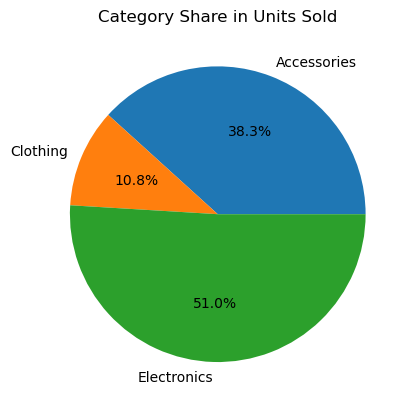

In [2]:
import matplotlib.pyplot as plt

# Units sold per category
units_sold = df.groupby("Category")["UnitsSold"].sum()

plt.pie(units_sold, labels=units_sold.index, autopct="%1.1f%%")
plt.title("Category Share in Units Sold")
plt.show()


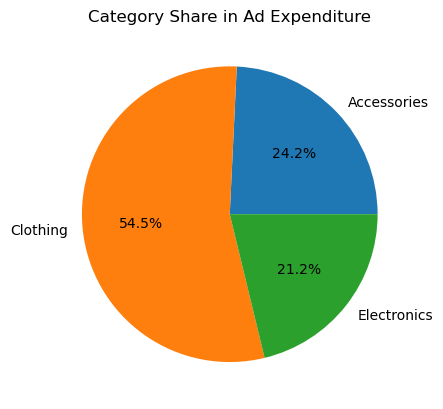

In [3]:
# Ad spend per category
ad_spend = df.groupby("Category")["AdSpend"].sum()

plt.pie(ad_spend, labels=ad_spend.index, autopct="%1.1f%%")
plt.title("Category Share in Ad Expenditure")
plt.show()


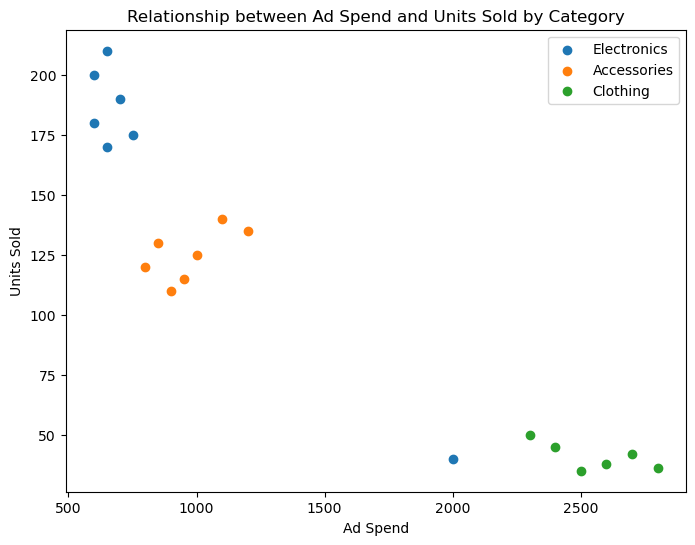

In [4]:
import matplotlib.pyplot as plt

# Scatter plot: AdSpend vs UnitsSold
plt.figure(figsize=(8,6))

for category in df["Category"].unique():
    subset = df[df["Category"] == category]
    plt.scatter(subset["AdSpend"], subset["UnitsSold"], label=category)

plt.xlabel("Ad Spend")
plt.ylabel("Units Sold")
plt.title("Relationship between Ad Spend and Units Sold by Category")
plt.legend()
plt.show()


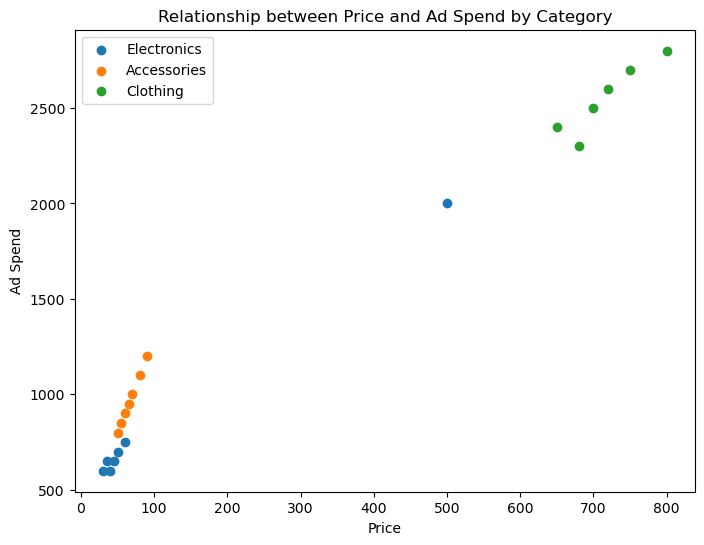

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot: Price vs AdSpend
for category in df["Category"].unique():
    subset = df[df["Category"] == category]
    plt.scatter(subset["Price"], subset["AdSpend"], label=category)

plt.xlabel("Price")
plt.ylabel("Ad Spend")
plt.title("Relationship between Price and Ad Spend by Category")
plt.legend()
plt.show()


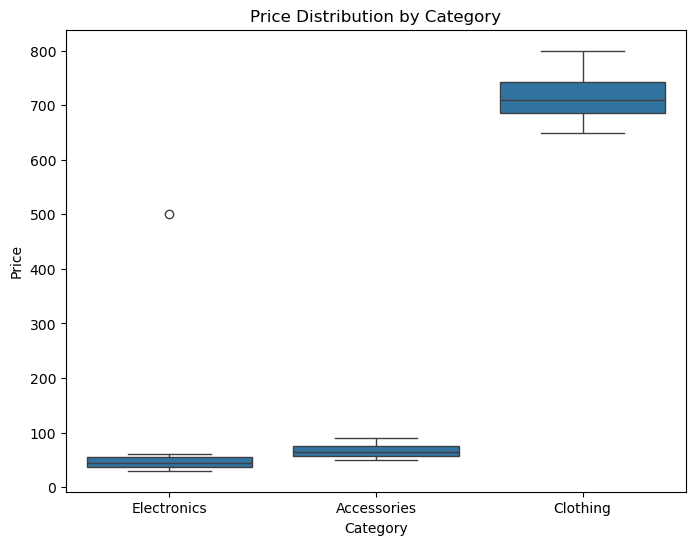

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x="Category", y="Price", data=df)
plt.title("Price Distribution by Category")
plt.show()


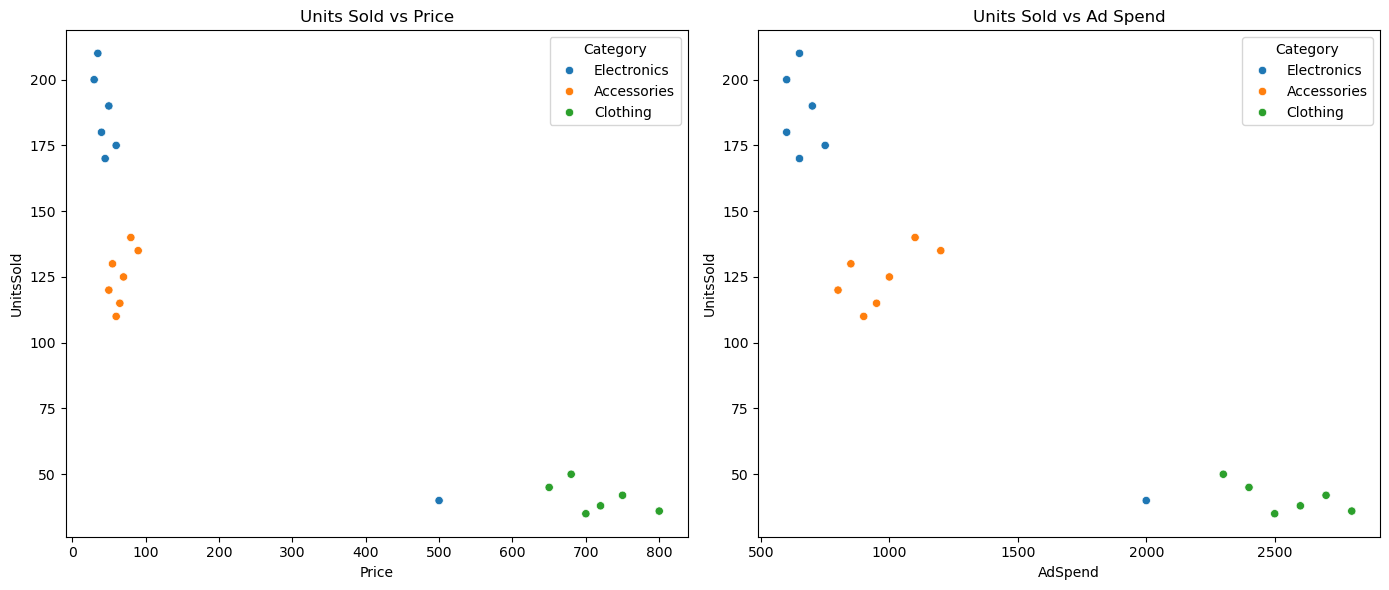

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Units Sold vs Price
sns.scatterplot(x="Price", y="UnitsSold", hue="Category", data=df, ax=axes[0])
axes[0].set_title("Units Sold vs Price")

# Units Sold vs AdSpend
sns.scatterplot(x="AdSpend", y="UnitsSold", hue="Category", data=df, ax=axes[1])
axes[1].set_title("Units Sold vs Ad Spend")

plt.tight_layout()
plt.show()


Category
Accessories     52525
Clothing       160110
Electronics     62250
Name: Income, dtype: int64


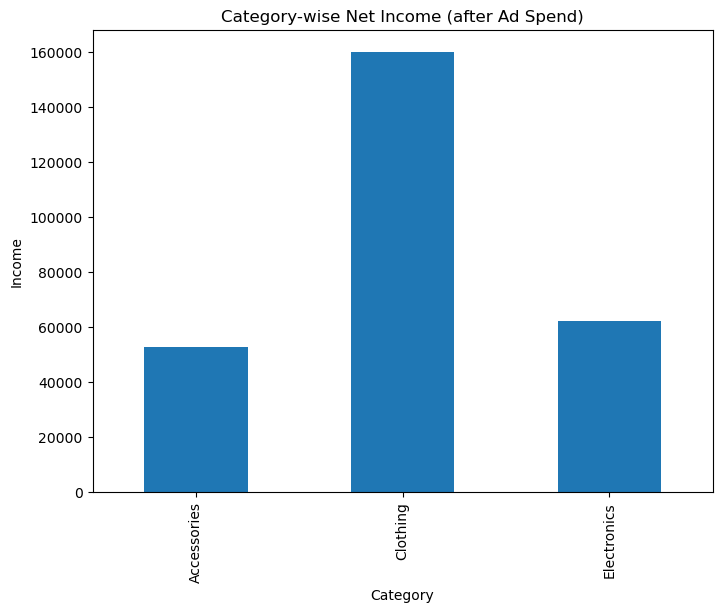

In [8]:
df["Income"] = (df["Price"] * df["UnitsSold"]) - df["AdSpend"]

category_income = df.groupby("Category")["Income"].sum()
print(category_income)

# Optional: visualize with bar plot
category_income.plot(kind="bar", figsize=(8,6))
plt.title("Category-wise Net Income (after Ad Spend)")
plt.ylabel("Income")
plt.show()
